<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Selección de Modelos, Validación Cruzada y Regresión k-NN 🎯
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 07
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

---
## Guía de Aprendizaje del Cuaderno 🧭

En los cuadernos anteriores abordamos la formulación matemática de la **Regresión Lineal**, las complejidades del **sobreajuste y la multicolinealidad**, y el control de complejidad mediante **Regresión Polinomial y Regularización (Ridge y Lasso)**.

En este cuaderno consolidamos el flujo profesional de **Selección y Evaluación de Modelos**:
1. **El Dilema de la Partición Hold-Out:** Por qué una sola división Train/Test puede ser engañosa e inestable en datasets pequeños o medianos.
2. **Validación Cruzada ($k$-Fold CV):** La técnica estándar para estimar el error de generalización de forma insesgada.
3. **Automatización con Scikit-Learn:** Uso de `cross_val_score`, configuración de `scoring` y prevención de *Data Leakage* mediante `Pipeline`.
4. **Pruebas de Hipótesis Estadísticas:** Inferencia rigurosa sobre los coeficientes ($t$-test) y el modelo global ($F$-test) con `statsmodels`.
5. **Regresión No Paramétrica ($k$-NN Regressor):** Fundamentos teóricos del aprendizaje local basado en distancias.
6. **Caso Práctico Capital Bikeshare:** Análisis exploratorio, modelado comparativo ($k$-NN vs Regresión Lineal) y optimización de hiperparámetros.

In [1]:
# =============================================================================
# Configuración del Entorno de Trabajo
# =============================================================================
try:
    from IPython.core.interactiveshell import InteractiveShell
    InteractiveShell.ast_node_interactivity = 'all'
except Exception:
    pass
try:
    from IPython.display import display
except Exception:
    pass

import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pandas.api.types import CategoricalDtype

# Scikit-Learn: Validación cruzada, modelos, pipelines y métricas
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn import metrics

# Inferencia estadística formal
import statsmodels.api as sm

# Estilo visual institucional
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["font.size"] = 10

np.random.seed(42)
print("✅ Entorno configurado exitosamente.")

✅ Entorno configurado exitosamente.


---
### 1. El Método Hold-Out y sus Limitaciones Estadísticas 📉

Para evaluar el rendimiento de un modelo de Machine Learning y seleccionar los mejores hiperparámetros, la práctica más elemental consiste en dividir el dataset en dos particiones disyuntas: **Entrenamiento (*Train*)** y **Prueba (*Test*)** (conocido como método *Hold-Out*).

```
┌────────────────────────────────────────────────────────────────────────┐
│                   Conjunto Total de Datos (100%)                       │
└───────────────────────────────────┬────────────────────────────────────┘
                                    │
            ┌───────────────────────┴───────────────────────┐
            ▼                                               ▼
┌───────────────────────────────────────┐       ┌───────────────────────┐
│     Conjunto de Entrenamiento (80%)   │       │   Conjunto Test (20%) │
│      • Ajuste de parámetros β         │       │ • Evaluación final    │
│      • Aprendizaje de patrones        │       │ • Estimación de error │
└───────────────────────────────────────┘       └───────────────────────┘
```

#### ¿Por qué el método Hold-Out puede fallar en datasets pequeños/medianos?
1. **Alta Variabilidad en el Puntaje de Prueba:** Si el conjunto de prueba es reducido, la métrica calculada depende excesivamente de la fortuna con que se repartieron las filas en la división aleatoria.
2. **Pérdida de Información Útil:** Reservar un $20\%$ o $30\%$ de los datos únicamente para test priva al modelo de valiosas observaciones durante la fase de entrenamiento.
3. **Sobreestimación Pesimista del Error:** Los modelos ajustados con menos datos suelen rendir por debajo de su capacidad real, sobreestimando el error de generalización.

* **Ejemplo Intuitivo:** En un dataset de $500$ filas, si reservamos el $20\%$ ($100$ filas) para validación, dos particiones aleatorias distintas pueden dar conclusiones totalmente opuestas sobre cuál modelo es el mejor.
* **Caso Extremo:** Con solo $1$ fila de validación, la selección de modelos sería equivalente a un sorteo por puro azar.

> 📌 **Solución:** Cuando no disponemos de millones de datos, la **Validación Cruzada (*Cross-Validation*)** permite rotar sistemáticamente las particiones para que **cada dato sea usado para entrenar y para evaluar**.

---
### 2. Validación Cruzada ($k$-Fold Cross-Validation) 🔄

En la **Validación Cruzada en $k$ pliegues ($k$-Fold CV)**, dividimos el conjunto de datos en $k$ subconjuntos de tamaño aproximadamente igual:

<div align="center">
  <img src="images/cross_val.png" width="620" alt="k-Fold Cross Validation Schema" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 15px 0;"/>
  <p style="font-size: 0.85em; color: #64748b;">
    <i>Figura: Esquema de 5-Fold Cross-Validation. En cada una de las 5 rondas, un pliegue actúa como validación mientras los 4 restantes entrenan el modelo.</i>
  </p>
</div>

#### Procedimiento Iterativo:
1. **Ronda 1:** Entrenar con los pliegues $[2, 3, 4, 5]$ $\to$ Evaluar en el pliegue $1$ $\to \text{Score}_1$.
2. **Ronda 2:** Entrenar con los pliegues $[1, 3, 4, 5]$ $\to$ Evaluar en el pliegue $2$ $\to \text{Score}_2$.
3. **Rondas 3, 4 y 5:** Repetir rotando el pliegue de prueba.
4. **Puntaje Global de Validación:** Se calcula el promedio aritmético de las $k$ evaluaciones:
   $$\text{CV}_{(k)} = \frac{1}{k} \sum_{i=1}^k \text{Score}_i$$

* **Criterio Práctico:** El valor estándar por excelencia en la literatura científica es **$k = 5$** o **$k = 10$**, ya que ofrecen un balance óptimo entre sesgo y varianza computacional.

---
### 3. Automatización con `cross_val_score` y `Pipeline` 🛠️

Scikit-Learn provee la función **`cross_val_score`** en `sklearn.model_selection`, la cual automatiza los $k$ entrenamientos y evaluaciones en una sola línea.

#### Parámetros Principales de `cross_val_score`:

| Parámetro | Tipo / Default | Descripción y Uso Práctico |
| :--- | :--- | :--- |
| **`estimator`** | Estimador / `Pipeline` | Objeto que implementa `.fit()` y `.predict()`. |
| **`X`** | `array-like` | Matriz de predictores $(n \times p)$. |
| **`y`** | `array-like` | Vector objetivo $(n,)$. |
| **`scoring`** | `str` o `callable` | Métrica a optimizar. Por defecto usa el `.score()` del estimador ($R^2$ en regresión). |
| **`cv`** | `int` (default=5) | Cantidad de pliegues $k$ o generador de particiones (`KFold`). |
| **`n_jobs`** | `int` (default=None) | Núcleos de CPU para cómputo en paralelo (`-1` = todos los núcleos). |

#### Manejo de Métricas y Scorers con `make_scorer`:
La API de Scikit-Learn sigue la regla de **maximizar siempre el score**. Por ello:
* Métricas como $R^2$: `r2_scorer = make_scorer(r2_score, greater_is_better=True)`.
* Métricas de error (como MSE): se devuelven en negativo (`'neg_mean_squared_error'`).

> 💡 **La Importancia del `Pipeline`:**  
> Encapsular transformaciones como `PolynomialFeatures` dentro de un `Pipeline` garantiza que la transformación polinomial se aprenda **únicamente sobre los pliegues de entrenamiento** de cada ronda, evitando la fuga de información (*Data Leakage*).

🏆 Grado Polinomial Óptimo: d* = 2
📊 R² Promedio en Validación Cruzada (5-Fold): 0.978799
🎯 Test Score (R² en Conjunto de Prueba No Visto): 0.993273


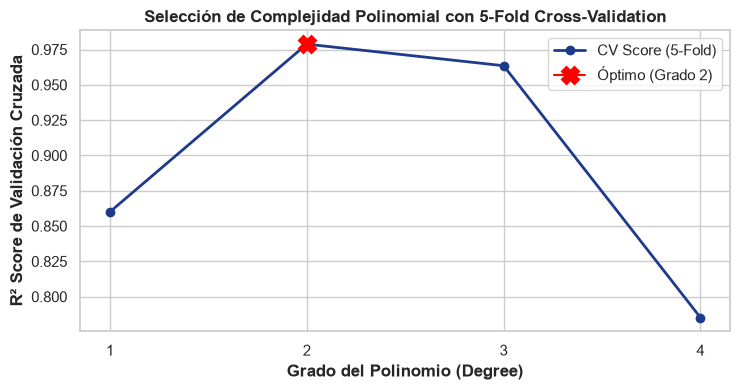

In [2]:
# =============================================================================
# Selección del Grado Polinomial Óptimo mediante 5-Fold Cross Validation
# =============================================================================

# 1. Carga del conjunto de datos Advertising
adv_data = pd.read_csv("data/Advertising.csv")
if 'Unnamed: 0' in adv_data.columns:
    adv_data = adv_data[['TV', 'Radio', 'Newspaper', 'Sales']]

X_features = ['TV', 'Radio', 'Newspaper']
X = adv_data[X_features].to_numpy()
y = adv_data['Sales'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=23)

# 2. Configuración del evaluador y búsqueda del mejor grado d en [1, 4]
# NOTE: The API always maximises the score, so score that
# must be minimized are returned as negative values!
r2_scorer = make_scorer(r2_score, greater_is_better=True)
# or ...
# mse_scorer = 'neg_mean_squared_error'

degree = list(range(1, 5))
val_scores = np.zeros(len(degree))

# Evaluación mediante Validación Cruzada
# NOTE: We don't need to explicitly train the model, the
# function will do it for us for each train split. Also
# train scores are not reported, only the cv score!
for i, d in enumerate(degree):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('linear', LinearRegression(fit_intercept=True))
    ])
    scores = cross_val_score(model, X_train, y_train, scoring=r2_scorer, cv=5)
    val_scores[i] = np.mean(scores)

# Identificar el grado que maximiza la validación cruzada
best_model_idx = np.argmax(val_scores)
best_degree = degree[best_model_idx]
best_val_score = val_scores[best_model_idx]

print("=" * 55)
print(f"🏆 Grado Polinomial Óptimo: d* = {best_degree}")
print(f"📊 R² Promedio en Validación Cruzada (5-Fold): {best_val_score:.6f}")
print("=" * 55)

# 3. Reentrenar el Pipeline final sobre todo el conjunto de entrenamiento
model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('linear', LinearRegression(fit_intercept=True))
])
model = model.fit(np.concatenate([X_train]), np.concatenate([y_train]))
y_predict = model.predict(X_test)
test_score = r2_score(y_test, y_predict)

print(f"🎯 Test Score (R² en Conjunto de Prueba No Visto): {test_score:.6f}")
print("=" * 55)

# 4. Curva de Validación Cruzada
plt.figure(figsize=(7.5, 4), dpi=100)
plt.plot(degree, val_scores, label="CV Score (5-Fold)", color="#1e3a8a", linewidth=2, marker='o')
plt.plot([best_degree], [best_val_score], marker="X", markersize=12, markeredgewidth=2, color="red", label=f"Óptimo (Grado {best_degree})")
plt.xlabel("Grado del Polinomio (Degree)", fontweight="bold")
plt.ylabel("R² Score de Validación Cruzada", fontweight="bold")
plt.title("Selección de Complejidad Polinomial con 5-Fold Cross-Validation", fontweight="bold")
plt.xticks(degree)
plt.legend()
plt.tight_layout()
plt.show()

---
### 4. Pruebas de Hipótesis Estadísticas en Regresión Lineal 📊

Antes de aceptar un modelo de regresión, la estadística inferencial nos permite comprobar si los patrones observados son reales o producto del ruido aleatorio:

#### Formulación de Hipótesis:
* **Hipótesis Nula ($H_0$):** Postula que **no existe efecto** del predictor sobre el target ($H_0: \beta_j = 0$).
* **Hipótesis Alternativa ($H_1$ o $H_a$):** Postula que **sí existe una relación estadísticamente significativa** ($H_1: \beta_j \neq 0$).
* **$p$-valor (*p-value*):** Es la probabilidad de observar un resultado tan extremo por puro azar si $H_0$ fuese cierta. Un $p\text{-valor} < 0.05$ rechaza $H_0$.

#### Las Dos Pruebas Clave:
1. **Prueba $t$ de Student (Individual):** Evalúa cada variable $j$ mediante su estadístico $t_j = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)}$.
2. **Prueba $F$ de Fisher (Global):** Evalúa si **todas las variables en conjunto** explican la variabilidad del target mejor que una simple constante ($H_0: \beta_1 = \beta_2 = \dots = \beta_p = 0$).

In [3]:
# =============================================================================
# Inferencia Estadística Formal con statsmodels.api.OLS
# =============================================================================
X_sm = sm.add_constant(adv_data[X_features])
ols_sm = sm.OLS(adv_data['Sales'], X_sm).fit()

# Tabla de coeficientes, errores estándar y p-valores
print(ols_sm.summary().tables[1])
print("\n" + "=" * 65)
print(f"Estadístico F Global: {ols_sm.fvalue:.2f} | p-valor F: {ols_sm.f_pvalue:.2e}")
print("=" * 65)
print("🔍 Diagnóstico Estadístico:")
print(" • 'TV' y 'Radio': p-valor < 0.001 (Rechazamos H0: son predictores altamente significativos).")
print(" • 'Newspaper':    p-valor = 0.860 > 0.05 (No rechazamos H0: su aporte individual no es significativo).")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.000       2.324       3.554
TV             0.0458      0.001     32.809      0.000       0.043       0.049
Radio          0.1885      0.009     21.893      0.000       0.172       0.206
Newspaper     -0.0010      0.006     -0.177      0.860      -0.013       0.011

Estadístico F Global: 570.27 | p-valor F: 1.58e-96
🔍 Diagnóstico Estadístico:
 • 'TV' y 'Radio': p-valor < 0.001 (Rechazamos H0: son predictores altamente significativos).
 • 'Newspaper':    p-valor = 0.860 > 0.05 (No rechazamos H0: su aporte individual no es significativo).


---
### 5. Regresión No Paramétrica: $k$-Vecinos Más Cercanos ($k$-NN) 🎯

A diferencia de la Regresión Lineal (que impone una estructura funcional global $\hat{y} = \mathbf{X}\boldsymbol{\beta}$), el algoritmo **$k$-NN (*$k$-Nearest Neighbors*)** es un método **no paramétrico** que estima el valor objetivo calculando el promedio local de los $k$ vecinos más próximos en el espacio de características:

$$\hat{y}(\mathbf{x}_0) = \frac{1}{k} \sum_{i \in \mathcal{N}_k(\mathbf{x}_0)} y_i$$

#### Características y Dilema Sesgo-Varianza en $k$-NN:
* **Hiperparámetro $k$ pequeño ($k=1$ o $k=2$):** Fronteras sumamente complejas y sensibles al ruido $\to$ **Alto sobreajuste (*Overfitting*)**.
* **Hiperparámetro $k$ grande:** Predicción muy suave e insensible a detalles locales $\to$ **Alto subajuste (*Underfitting*)**.
* **Métrica de Distancia:** Habitualmente Distancia Euclidiana ($L_2$) o Manhattan ($L_1$):
  $$d(\mathbf{x}_a, \mathbf{x}_b) = \sqrt{\sum_{j=1}^p (x_{aj} - x_{bj})^2}$$
* **Requisito Crítico de Escalado:** Como $k$-NN calcula distancias geométricas, **es obligatorio escalar las variables** (`MinMaxScaler` o `StandardScaler`) para que las características con magnitudes grandes no dominen artificialmente el cálculo.

---
### 6. Caso Práctico: Demanda Diaria de Alquiler de Bicicletas (*Capital Bikeshare*) 🚴

Utilizaremos el dataset de Capital Bikeshare en Washington D.C. (731 observaciones) para comparar empíricamente el comportamiento de **Regresión Lineal** frente a **$k$-NN Regressor**:

* `season`: Estación del año (1: Invierno, 2: Primavera, 3: Verano, 4: Otoño).
* `month`: Mes (1 a 12).
* `holiday`: Indicador de festivo.
* `day_of_week`: Día de la semana (0 a 6).
* `workingday`: Indicador de día laboral.
* `weather`: Condición climática (1: Despejado a 4: Tormenta/Nieve).
* `temp`: Temperatura ambiente (°C).
* `atemp`: Sensación térmica (°C).
* `humidity`: Humedad relativa (%).
* `windspeed`: Velocidad del viento.
* `count`: **Variable Objetivo** (total de alquileres diarios de bicicletas).

In [4]:
# Carga del dataset Bikeshare
bikeshare = pd.read_csv('data/bikeshare.csv')
print(f"Dimensiones del dataset: {bikeshare.shape[0]} filas × {bikeshare.shape[1]} columnas")
display(bikeshare.head())

Dimensiones del dataset: 731 filas × 11 columnas
   season  month  holiday  day_of_week  workingday  weather  temp  atemp  humidity  windspeed  count
0       2      5        0            2           1        2  24.0   26.0     76.58       0.12   6073
1       4     12        0            2           1        1  15.0   19.0     73.38       0.17   6606
2       2      6        0            4           1        1  26.0   28.0     56.96       0.25   7363
3       4     12        0            0           0        1   0.0    4.0     58.63       0.17   2431
4       3      9        0            3           1        3  23.0   23.0     91.71       0.10   1996


In [5]:
# 1. Comprobación de valores nulos
print("Valores nulos por columna:")
display(bikeshare.isnull().sum())

# 2. Conversión a tipos categóricos apropiados
cat_type = CategoricalDtype(ordered=False)
cat_vars = ['weather', 'day_of_week', 'holiday', 'season', 'month', 'workingday']
for var in cat_vars:
    if var in bikeshare.columns:
        bikeshare[var] = bikeshare[var].astype(cat_type)

bikeshare['count'] = bikeshare['count'].astype('int')
print("\nTipos de datos actualizados:")
display(bikeshare.dtypes)

Valores nulos por columna:
season         0
month          0
holiday        0
day_of_week    0
workingday     0
              ..
temp           0
atemp          0
humidity       0
windspeed      0
count          0

Tipos de datos actualizados:
season         category
month          category
holiday        category
day_of_week    category
workingday     category
                 ...   
temp            float64
atemp           float64
humidity        float64
windspeed       float64
count             int64


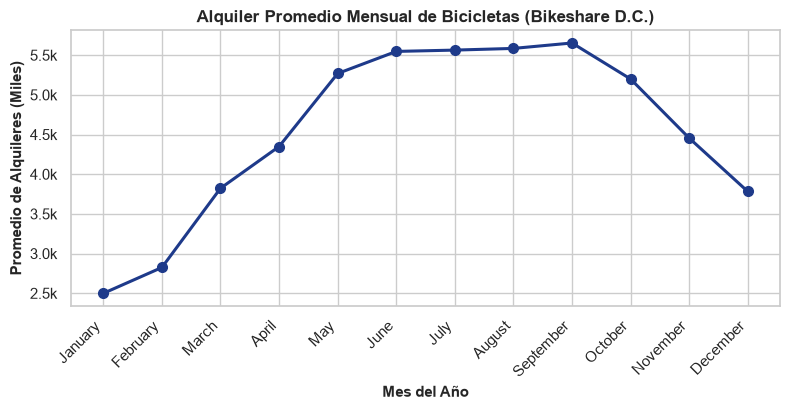

In [6]:
# Alquiler promedio de bicicletas por mes
ave_rentals_month = bikeshare.groupby('month', observed=False)['count'].mean()

# Gráfico de serie mensual
fig, ax = plt.subplots(figsize=[8, 4.2], dpi=100)
ax.plot(range(1, 13), ave_rentals_month.values, 'o-', linewidth=2.2, markersize=7, color='#1e3a8a')

ax.set_xlabel('Mes del Año', fontsize=11, fontweight='bold')
ax.set_ylabel('Promedio de Alquileres (Miles)', fontsize=11, fontweight='bold')
ax.set_title('Alquiler Promedio Mensual de Bicicletas (Bikeshare D.C.)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(lambda y, pos: f'{y/1000:.1f}k')
ax.set_xticks(range(1, 13))
ax.set_xticklabels([calendar.month_name[i] for i in range(1, 13)], rotation=45, ha='right')
plt.tight_layout()
plt.show()

Dimensiones de los conjuntos:
X_train: (511, 1) | y_train: (511,) | X_test: (220, 1) | y_test: (220,)


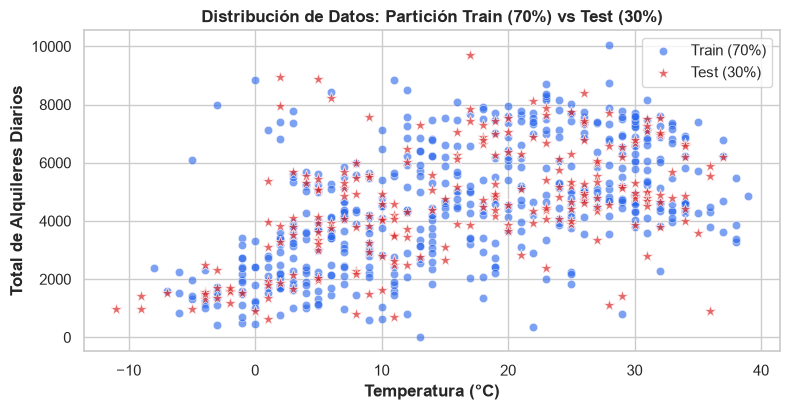

In [7]:
# Partición 70% entrenamiento / 30% prueba
response = 'count'
train_data, test_data = train_test_split(bikeshare, test_size=0.30, random_state=42)

X_train = train_data[['temp']]
y_train = train_data[response]
X_test = test_data[['temp']]
y_test = test_data[response]

print("Dimensiones de los conjuntos:")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape} | X_test: {X_test.shape} | y_test: {y_test.shape}")

# Gráfico de distribución Train vs Test
plt.figure(figsize=[8, 4.2], dpi=100)
sns.scatterplot(data=train_data, x='temp', y='count', label='Train (70%)', color='#2563eb', alpha=0.6)
sns.scatterplot(data=test_data, x='temp', y='count', label='Test (30%)', color='#dc2626', marker='*', s=80, alpha=0.7)
plt.xlabel('Temperatura (°C)', fontweight='bold')
plt.ylabel('Total de Alquileres Diarios', fontweight='bold')
plt.title("Distribución de Datos: Partición Train (70%) vs Test (30%)", fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Escalado de características con MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ajuste del estimador k-NN con k = 20
k = 20
knn_model = KNeighborsRegressor(n_neighbors=k)
knn_model.fit(X_train, y_train)

# Predicciones
pred_train_knn = knn_model.predict(X_train)
pred_test_knn = knn_model.predict(X_test)

# Evaluación
r2_train_knn = knn_model.score(X_train, y_train)
r2_test_knn = knn_model.score(X_test, y_test)
mse_train_knn = mean_squared_error(y_train, pred_train_knn)
mse_test_knn = mean_squared_error(y_test, pred_test_knn)

print(f"📊 RENDIMIENTO DEL MODELO k-NN (k = {k}):")
print("-" * 45)
print(f"• R² Train: {r2_train_knn:.3f} | MSE Train: {mse_train_knn:,.2f}")
print(f"• R² Test:  {r2_test_knn:.3f} | MSE Test:  {mse_test_knn:,.2f}")

📊 RENDIMIENTO DEL MODELO k-NN (k = 20):
---------------------------------------------
• R² Train: 0.353 | MSE Train: 2,732,513.21
• R² Test:  0.249 | MSE Test:  2,819,082.87


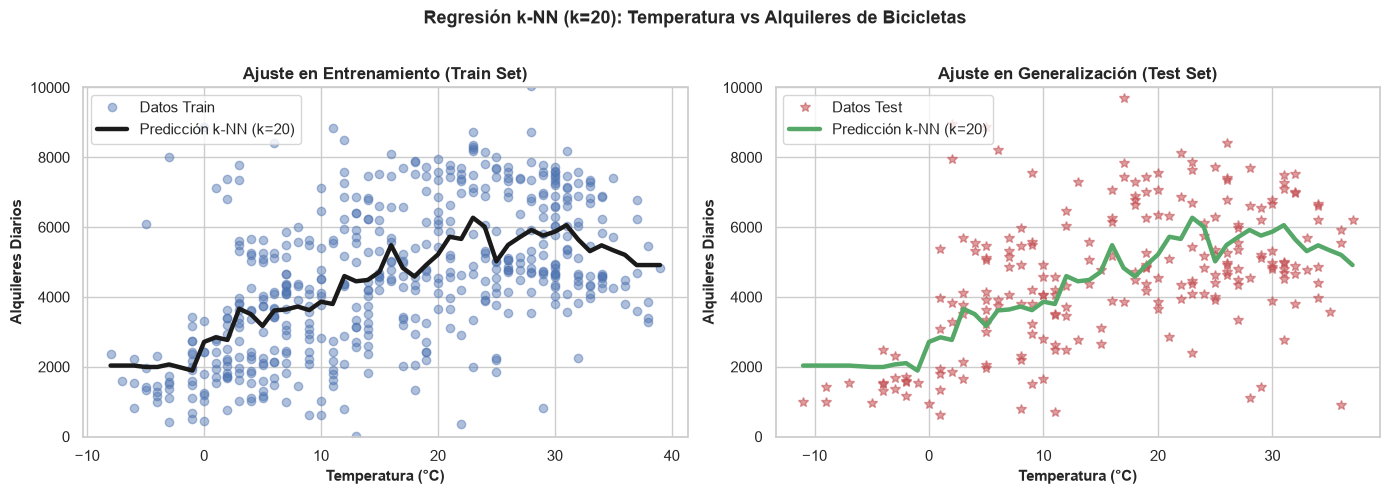

In [9]:
# Subplots comparativos de ajuste k-NN
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4.8), dpi=100)

# 1. Conjunto de Entrenamiento
axes[0].set_ylim([0, 10000])
axes[0].plot(train_data['temp'], train_data['count'], 'bo', alpha=0.45, label='Datos Train')
sorted_train = train_data.sort_values(['temp'])
pred_knn_sorted_train = knn_model.predict(sorted_train[['temp']])
axes[0].plot(sorted_train['temp'], pred_knn_sorted_train, 'k-', linewidth=3.2, label=f'Predicción k-NN (k={k})')
axes[0].set_xlabel('Temperatura (°C)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Alquileres Diarios', fontsize=11, fontweight='bold')
axes[0].set_title("Ajuste en Entrenamiento (Train Set)", fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left')

# 2. Conjunto de Prueba
axes[1].set_ylim([0, 10000])
axes[1].plot(test_data['temp'], test_data['count'], 'r*', alpha=0.55, markersize=7, label='Datos Test')
sorted_test = test_data.sort_values(['temp'])
pred_knn_sorted_test = knn_model.predict(sorted_test[['temp']])
axes[1].plot(sorted_test['temp'], pred_knn_sorted_test, 'g-', linewidth=3.2, label=f'Predicción k-NN (k={k})')
axes[1].set_xlabel('Temperatura (°C)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Alquileres Diarios', fontsize=11, fontweight='bold')
axes[1].set_title("Ajuste en Generalización (Test Set)", fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left')

fig.suptitle(f"Regresión k-NN (k={k}): Temperatura vs Alquileres de Bicicletas", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Ajuste de Regresión Lineal sobre el mismo conjunto
x_train_lr, y_train_lr = train_data[['temp']], train_data[response]
x_test_lr, y_test_lr = test_data[['temp']], test_data[response]

lr_model = LinearRegression().fit(x_train_lr, y_train_lr)

y_pred_train_lr = lr_model.predict(x_train_lr)
y_pred_test_lr = lr_model.predict(x_test_lr)

r2_train_lr = r2_score(y_train_lr, y_pred_train_lr)
r2_test_lr = r2_score(y_test_lr, y_pred_test_lr)
mse_train_lr = mean_squared_error(y_train_lr, y_pred_train_lr)
mse_test_lr = mean_squared_error(y_test_lr, y_pred_test_lr)

print("📊 RENDIMIENTO DE REGRESIÓN LINEAL:")
print("-" * 45)
print(f"• Pendiente (β1): {lr_model.coef_[0]:.3f} | Intercepto (β0): {lr_model.intercept_:.3f}")
print(f"• R² Train: {r2_train_lr:.3f} | MSE Train: {mse_train_lr:,.2f}")
print(f"• R² Test:  {r2_test_lr:.3f} | MSE Test:  {mse_test_lr:,.2f}")

📊 RENDIMIENTO DE REGRESIÓN LINEAL:
---------------------------------------------
• Pendiente (β1): 94.823 | Intercepto (β0): 2996.287
• R² Train: 0.282 | MSE Train: 3,031,302.44
• R² Test:  0.224 | MSE Test:  2,915,373.46


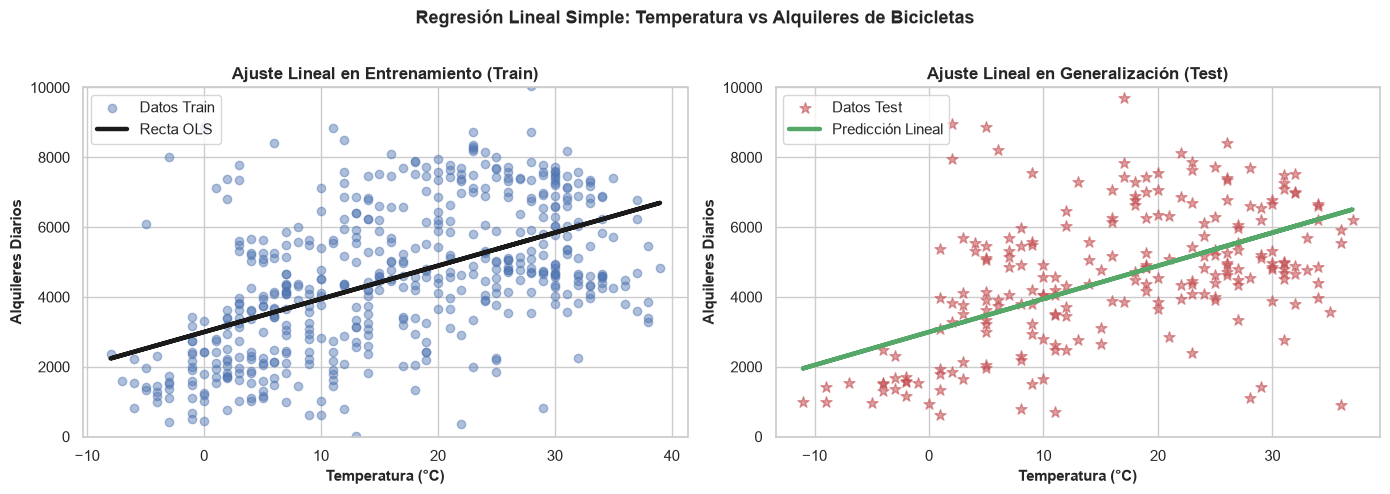

In [11]:
# Subplots de la recta de regresión lineal
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), dpi=100)

# Train Set
axes[0].scatter(x_train_lr, y_train_lr, color='b', alpha=0.45, label='Datos Train')
axes[0].plot(x_train_lr, y_pred_train_lr, 'k-', linewidth=3.2, label='Recta OLS')
axes[0].set_title('Ajuste Lineal en Entrenamiento (Train)', fontsize=12, fontweight='bold')

# Test Set
axes[1].scatter(x_test_lr, y_test_lr, color='r', marker='*', s=70, alpha=0.55, label='Datos Test')
axes[1].plot(x_test_lr, y_pred_test_lr, 'g-', linewidth=3.2, label='Predicción Lineal')
axes[1].set_title('Ajuste Lineal en Generalización (Test)', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_ylim(0, 10000)
    ax.set_xlabel('Temperatura (°C)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Alquileres Diarios', fontsize=11, fontweight='bold')
    ax.legend(loc='upper left')

fig.suptitle('Regresión Lineal Simple: Temperatura vs Alquileres de Bicicletas', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### 7. Comparación Teórica y Empírica: Paramétrico vs No Paramétrico ⚖️

| Criterio | Regresión Lineal (Paramétrico) | $k$-NN Regressor (No Paramétrico) |
| :--- | :--- | :--- |
| **Supuesto Estructural** | Asume relación lineal global ($\hat{y} = \beta_0 + \beta_1 x$). | No asume ninguna forma funcional previa. |
| **Interpretabilidad** | Coeficientes directos y claros ($\beta_j$). | Caja negra local basada en vecindades. |
| **Complejidad Computacional** | Muy rápida en entrenamiento e inferencia ($O(p)$). | Costosa en inferencia ($O(n \cdot p)$ por predicción). |
| **Adaptación a No Linealidades**| Requiere crear términos polinomiales manualmente. | Se adapta de forma natural a cualquier curvatura. |
| **Sensibilidad a Escalas** | Invariante ante cambios de escala de características. | **Extremadamente sensible**; requiere escalado obligatorio. |

---
##### 🛠️ Práctica 1: Optimización de $k$ en Bikeshare mediante 5-Fold Cross Validation

El valor $k=20$ fue fijado arbitrariamente. Utiliza validación cruzada para encontrar el número óptimo de vecinos $k^* \in [1, 50]$ que maximice el coeficiente de determinación $R^2$.

**Instrucciones:**
1. Itera sobre una lista de valores $k = 1, 2, \dots, 50$.
2. En cada iteración, evalúa el modelo con `cross_val_score(KNeighborsRegressor(n_neighbors=k), X_train, y_train, cv=5, scoring='r2')`.
3. Calcula el $R^2$ medio de validación para cada $k$.
4. Grafica la curva de validación cruzada de $R^2$ vs $k$ e identifica el valor óptimo $k^*$.
5. Reentrena el estimador con $k^*$ y compáralo contra la Regresión Lineal en el conjunto de prueba.

In [ ]:
# =========================================================================
# TU SOLUCIÓN: Optimización de k mediante Validación Cruzada en Bikeshare
# =========================================================================

# k_range = range(1, 51)
# cv_scores = []

# 1. Bucle de validación cruzada
# for k_val in k_range:
#     ...

# 2. Encontrar el mejor k
# best_k = ...

# 3. Graficar curva
# plt.plot(...)


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
k_range = range(1, 51)
cv_scores = []

# 1. Bucle de evaluación con 5-Fold CV
for k_val in k_range:
    knn = KNeighborsRegressor(n_neighbors=k_val)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='r2')
    cv_scores.append(np.mean(scores))

# 2. Identificación del mejor k
best_k_idx = np.argmax(cv_scores)
best_k = list(k_range)[best_k_idx]
best_cv_score = cv_scores[best_k_idx]

print("=" * 55)
print(f"🎯 HIPERPARÁMETRO ÓPTIMO: k* = {best_k}")
print(f"• R² Promedio en Validación Cruzada: {best_cv_score:.4f}")
print("=" * 55)

# 3. Gráfico de Optimización
plt.figure(figsize=(8, 4), dpi=100)
plt.plot(k_range, cv_scores, color='#1e3a8a', linewidth=2, label='R² 5-Fold CV')
plt.plot([best_k], [best_cv_score], marker='X', color='red', markersize=12, label=f'Óptimo (k={best_k})')
plt.xlabel('Número de Vecinos (k)', fontweight='bold')
plt.ylabel('R² Score de Validación', fontweight='bold')
plt.title('Curva de Optimización de Hiperparámetro k (Bikeshare)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Evaluación en Test con el modelo óptimo
best_knn = KNeighborsRegressor(n_neighbors=best_k).fit(X_train, y_train)
test_r2_knn = best_knn.score(X_test, y_test)
print(f"• R² en Test con k*={best_k}: {test_r2_knn:.4f}")
```
</details>

---
### 8. Resumen Conceptual del Módulo de Regresión 📌

1. **Validación Cruzada ($k$-Fold CV):** Elimina el sesgo y la alta variabilidad del método Hold-Out tradicional en muestras finitas, permitiendo que cada dato sea evaluado.
2. **Encapsulamiento en Pipelines:** Garantiza que los escaladores y expansiones polinomiales se calculen estrictamente dentro de los pliegues de entrenamiento, protegiendo contra la fuga de datos (*Data Leakage*).
3. **Inferencia Estadística:** La prueba $t$ y la prueba $F$ proporcionan el respaldo formal para validar que los predictores no son producto de fluctuaciones muestrales aleatorias.
4. **Paramétrico vs No Paramétrico:**
   * La **Regresión Lineal** ofrece interpretabilidad y eficiencia analítica insuperables cuando los supuestos de Gauss-Markov se cumplen.
   * **$k$-NN Regressor** captura patrones no lineales intrincados sin supuestos funcionales, pero requiere estandarización estricta y afinamiento de hiperparámetros.

### 📚 Recursos Adicionales:
* **[Scikit-Learn: Cross-Validation Guide](https://scikit-learn.org/stable/modules/cross_validation.html)**.
* **[Scikit-Learn: Nearest Neighbors Regression](https://scikit-learn.org/stable/modules/neighbors.html#nearest-neighbors-regression)**.
* **[Capital Bikeshare Dataset (UCI Repository)](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset)**.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>